# ENSO_amplitude: Variability of SST Anomalies in the Central Equatorial Pacific  

Computes the standard deviation of sea surface temperature anomalies (SSTA) in the Niño3.4 region (horizontal average over 5°S–5°N, 170°W–120°W) to evaluate the amplitude of variability in the central equatorial Pacific, a key characteristic of ENSO events.  

## Datasets Used for Amplitude Comparison  

The following reference datasets are used to evaluate the amplitude of ENSO-related SST anomalies in model simulations:  

- **TropFlux (1979–2018)**: The primary dataset for comparison, offering high-quality surface fluxes and anomalies tailored for tropical climate analysis.  

Additional datasets include:  
- **20CRv2 (1871–2012)**: A long-term reanalysis dataset reconstructing global atmospheric conditions using surface pressure observations.  
- **ERA-Interim (1979–2018)**: A high-resolution reanalysis product providing consistent estimates of atmospheric and surface variables.  
- **ERSSTv5 (1854–2018)**: A globally gridded dataset optimised for long-term SST anomaly analysis and ENSO studies.  
- **HadISST (1870–2018)**: A comprehensive dataset of historical SST and sea ice observations combined with reconstructions.  
- **NCEP2 (1979–2018)**: A second-generation reanalysis dataset delivering improved global atmospheric and surface data.  

## Dask Cluster 

Start a cluster with multiple cores 

In [1]:
from dask.distributed import Client, progress
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:173: ResourceWarning: unclosed <socket.socket fd=60, family=2, type=1, proto=6, laddr=('0.0.0.0', 0)>
  if retries_left < 1:
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41229 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/41229/status,
Dashboard: /proxy/41229/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46763,Workers: 0
Dashboard: /proxy/41229/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39567,Total threads: 4
Dashboard: /proxy/38753/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:39329,


## Datasets

In [2]:
from esmvalcore.dataset import Dataset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_object.py:639: ESMValCoreDeprecationWarning: Usage of the single configuration file ~/.esmvaltool/config-user.yml or specifying it via CLI argument `--config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please run `mkdir -p ~/.config/esmvaltool && mv /home/548/cxc548/.esmvaltool/config-user.yml ~/.config/esmvaltool` (or alternatively use a custom `--config_dir`) and omit `--config_file`.
  config_obj.reload()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, rem

In [3]:
model_ctrldatasets = {
"ACCESS-ESM1-5": 
    Dataset(
    short_name='ts',
    project='CMIP6',
    mip="Amon",
    exp="piControl",
    ensemble="r1i1p1f1",
    timerange="0900101/11000101",
    dataset="ACCESS-ESM1-5",
    grid="gn"
),
## Note: It is possible to use tos (sea_surface_temperature; degC; ocean; mon) 
# "ACCESS-ESM1-5": 
#     Dataset(
#     short_name='tos',
#     project='CMIP6',
#     mip="Omon",
#     exp="historical",
#     ensemble="r1i1p1f1",
#     timerange="18500101/20190101",
#     dataset="ACCESS-ESM1-5",
#     grid="gn"
# )
}

obs_datasets = {
"HadISST": 
    Dataset(
    short_name='ts',
    dataset='HadISST',
    mip="Amon",
    project='OBS',
    type='reanaly',
    tier=2),
# "ERSSTv5":
#     Dataset(
#     short_name='tos',
#     dataset='NOAA-ERSSTv5',
#     mip="Omon",
#     project='OBS6',
#     type='reanaly',
#     tier=2),

}

## Add Ancillary files

In [4]:
for name, dataset in model_ctrldatasets.items():
    dataset.add_supplementary(short_name='sftlf', mip="fx")
    dataset.add_supplementary(short_name="areacella", mip="fx")

In [5]:
model_ctrldatasets = {name: dataset.load() for name, dataset in model_ctrldatasets.items()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

import iris
from iris.util import equalise_attributes

#filename  = "/scratch/p66/yz9299/MOPPeR_outputs/CMIP6/CMIP/CSIRO/ACCESS-ESM1-6/piControl-spinup/r1i1p1f1/Amon/ts/gn/v20250801/*nc"
filename = "/scratch/p66/fc6164/MOPPeR/ts_Amon_ACCESS-ESM1-5_piControl_r1i1p1f1_gn_159201-209112.nc"

esm16cube = iris.load_cube(filename,'surface_temperature')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_validators.py:405: ESMValCoreDeprecationWarning: The configuration option or command line argument `config_file` has been deprecated in ESMValCore version 2.12.0 and is scheduled for removal in version 2.14.0. Please use the option `config_dir` instead.
  _handle_deprecation(option, deprecated_version, remove_version, more_info)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/esmvalcore/config/_config_valid

In [6]:
from esmvalcore.preprocessor import anomalies
from esmvalcore.preprocessor import area_statistics
from esmvalcore.preprocessor import climate_statistics
from esmvalcore.preprocessor import monthly_statistics
from esmvalcore.preprocessor import convert_units
from esmvalcore.preprocessor import extract_region
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import extract_month
from esmvalcore.preprocessor import regrid
from esmvalcore.preprocessor import detrend
from esmvalcore.preprocessor import axis_statistics
from esmvalcore.preprocessor import extract_time
from esmvalcore.preprocessor import mask_landsea
import iris
import numpy as np

import matplotlib.pyplot as plt
import iris.quickplot as qplt


In [12]:
# diag level 2 & 3
def preproc(cube,start,end):
    nino34_latext_region = {"start_longitude": 120., "end_longitude": 280., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube,period='monthly')
    cube = axis_statistics(cube,axis='y', operator='mean')
    # compute temporal standard deviation
    cube = climate_statistics(cube, operator="std_dev", period="full")
    return cube
    
def preproc3(cube,start,end): # extents and no axis statistics
    nino34_latext_region = {"start_longitude": 120., "end_longitude": 280., "start_latitude": -15., "end_latitude": 15.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino34_latext_region)
    cube = anomalies(cube,period='monthly')
    # compute temporal standard deviation
    cube = climate_statistics(cube, operator="std_dev", period="full")
    return cube

## sst_std for diag 1
def preproc_one(cube,start,end):
    nino34_latext_region = {"start_longitude": 190., "end_longitude": 240., "start_latitude": -5., "end_latitude": 5.}
    cube = extract_time(cube, start_year=start, start_month=1, start_day=1, end_year=end, end_month=12, end_day=31)    
    cube = convert_units(cube, units="degC")
    cube = mask_landsea(cube, mask_out="land")
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    cube = extract_region(cube, **nino34_latext_region)
    # remove seasonal cycle
    cube = anomalies(cube, period='monthly')
    cube = detrend(cube, dimension="time", method="linear")
    cube = area_statistics(cube, operator='mean')
    # compute temporal standard deviation
    cube = climate_statistics(cube, operator="std_dev", period="full")
    return cube

    
def compute(obs, mod):
    return abs((mod-obs)/obs)*100

In [13]:
model_ctrldatasets_prep = {name: preproc_one(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep = preproc_one(esm16cube,1800,2000) 
obs_datasets_prep = {name: preproc_one(dataset,1900,2014) for name, dataset in obs_datasets.items()}

model_ctrldatasets_prep2 = {name: preproc(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep2 = preproc(esm16cube,1800,2000) 

obs_datasets_prep2 = {name: preproc(dataset,1900,2014) for name, dataset in obs_datasets.items()}


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/ma/core.py:5417: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/ma/core.py:5417: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/ma/core.py:5417: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(

## Diagnostic Level 1

The first level shows the diagnostic used to compute the metric and highlight the difference between the model and the reference.

Text(0.75, 0.8, '* observation')

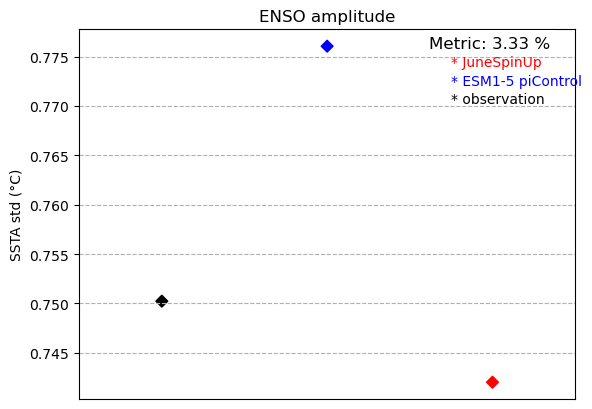

In [16]:
# plot
metric = [obs_datasets_prep["HadISST"].data.item(),model_ctrldatasets_prep["ACCESS-ESM1-5"].data.item(),model_datasets_prep.data ]

plt.scatter(range(len(metric)), metric, c=['black','blue','red'], marker='D')

plt.xlim(-0.5,2.5)#range(-1,3,1)) #['model','obs']
plt.xticks([])

plt.ylabel('SSTA std (°C)')
plt.grid(linestyle='--', axis='y')
plt.title('ENSO amplitude')

metricval = compute(metric[1],metric[0])

plt.text(0.95, 0.95, f'Metric: {metricval:.2f} %', fontsize=12, ha='right', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.text(0.75,0.9, '* JuneSpinUp', color='red',transform=plt.gca().transAxes)

plt.text(0.75,0.85, '* ESM1-5 piControl', color='blue',transform=plt.gca().transAxes)
plt.text(0.75,0.8, '* observation', color='black',transform=plt.gca().transAxes)


Figure 1: Standard deviation of sea surface temperature anomalies (SSTA) in the central equatorial Pacific (Niño 3.4 region average), representing the amplitude of variability. The model amplitude is typically close to the reference but slightly weaker. Black markers indicate the reference data, while blue markers represent the model. The derived metric is the absolute relative difference, calculated as: 
abs
(
(
model
−
ref
)
/
ref
)
×
100
abs((model−ref)/ref)×100.

## Diagnostic Level 2

The second level shows the zonal structure of the ENSO amplitude: the standard deviation of the anomalies along the equator in the Pacific.

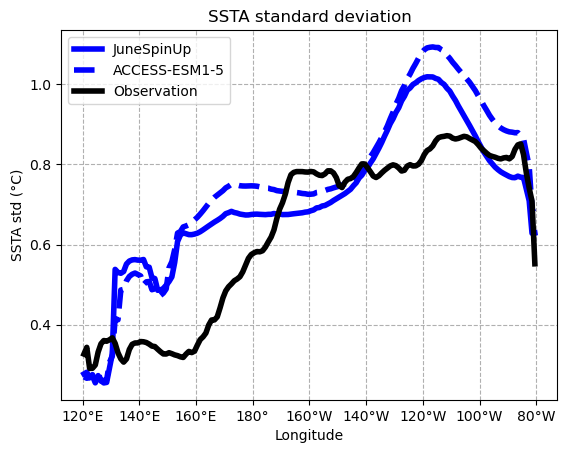

In [18]:

## diag 2 plot
def format_longitude(x, pos):
    if x > 180:
        return f'{int(360 - x)}°W'
    elif x == 180:
        return f'{int(x)}°'
    else:
        return f'{int(x)}°E'

qplt.plot(model_datasets_prep2, label="JuneSpinUp", linewidth=4,color='blue')

qplt.plot(model_ctrldatasets_prep2["ACCESS-ESM1-5"], label="ACCESS-ESM1-5", linewidth=4,color='blue',linestyle='--')
qplt.plot(obs_datasets_prep2["HadISST"], color='black', label='Observation', linewidth=4)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_longitude))

# Adding labels and title
plt.xlabel('Longitude')
plt.ylabel('SSTA std (°C)')
plt.title('SSTA standard deviation')
plt.grid(linestyle='--')
plt.legend()


Figure 2: Zonal structure of the standard deviation of sea surface temperature anomalies (SSTA) in the equatorial Pacific (averaged between 5°S and 5°N). The figure highlights the model's tendency to overestimate maximum variability in the central equatorial Pacific and west of the dateline. The black curve represents the reference data, while the blue curve corresponds to the model output.

## Diagnostic level 3

In [19]:

model_ctrldatasets_prep3 = {name: preproc3(dataset,900,1100) for name, dataset in model_ctrldatasets.items()}
model_datasets_prep3 = preproc3(esm16cube,1800,2000)
obs_datasets_prep3 = {name: preproc3(dataset,1900,2014) for name, dataset in obs_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/ma/core.py:5417: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/ma/core.py:5417: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(axis=axis, dtype=dtype, out=out, ddof=ddof,
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/numpy/ma/core.py:5417: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = super().var(

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.07/lib/python3.11/site-packages/iris/fileformats/netcdf/_thread_safe_nc.py:340: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  var = variable[keys]


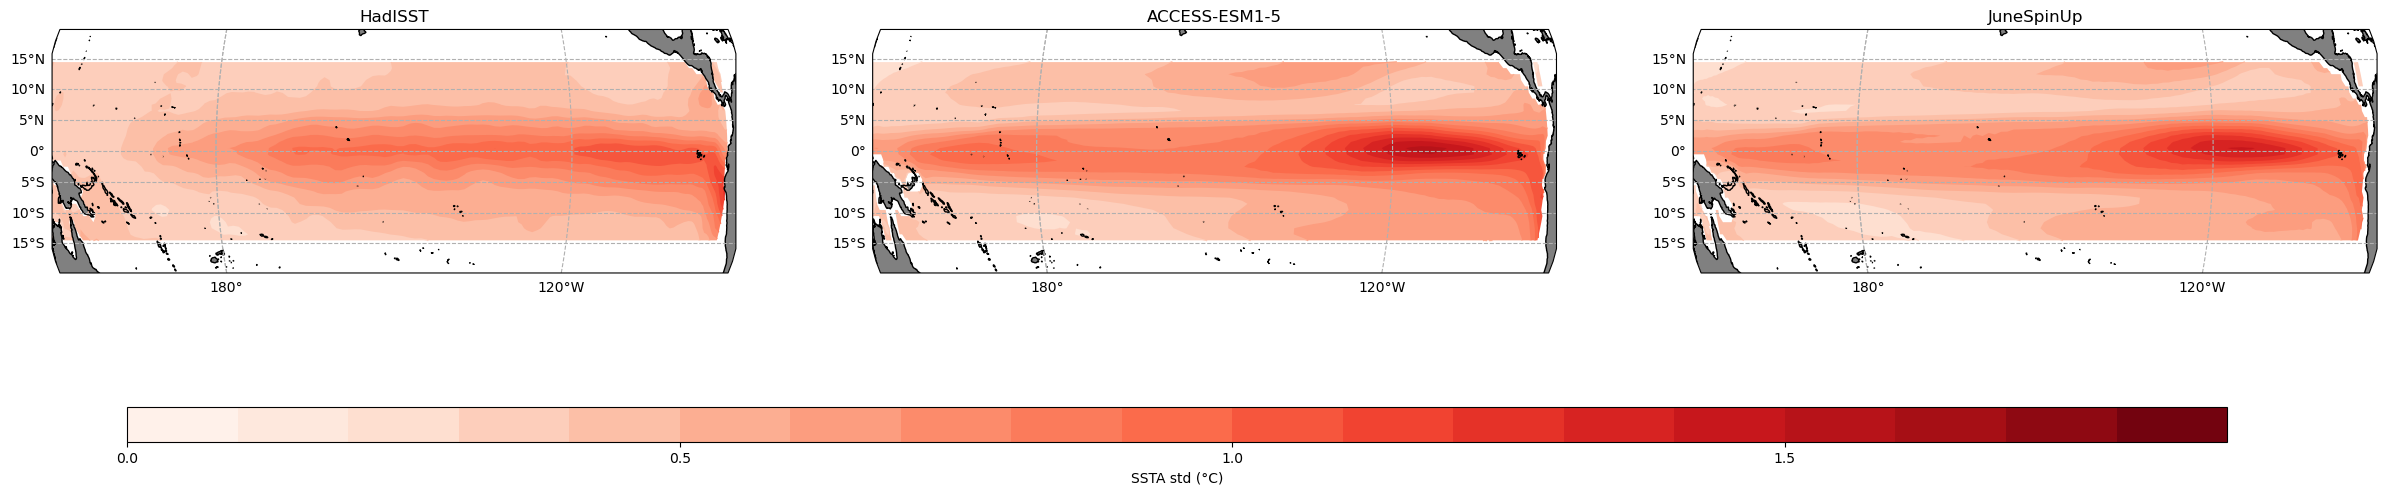

In [22]:
import iris.plot as iplt
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import cartopy.crs as ccrs

fig = plt.figure(figsize=(30, 7))
proj = ccrs.Orthographic(central_longitude=210.0)
i =131
process = { **obs_datasets_prep3,**model_ctrldatasets_prep3,"JuneSpinUp":model_datasets_prep3}


for label, cube in process.items():
    
    ax1 = plt.subplot(i,projection=proj)
    ax1.add_feature(cfeature.LAND, facecolor='gray')  # Add land feature with gray color
    ax1.coastlines()
    cf1 = iplt.contourf(cube, levels=np.arange(0,2,0.1), cmap='Reds')

    ax1.set_extent([130, 290, -20, 20], crs=ccrs.PlateCarree())
    ax1.set_title(label)

    # Add gridlines for latitude and longitude
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False

    i+=1


# Add a single colorbar at the bottom
cax = plt.axes([0.15,0.08,0.7,0.05])
cbar = fig.colorbar(cf1, cax=cax, orientation='horizontal', extend='both', ticks=np.arange(0,2,0.5))
cbar.set_label('SSTA std (°C)')

Figure 3: spatial structure of the standard deviation of sea surface temperature anomalies (SSTA) in the equatorial Pacific, showing usually a too weak variability off South America, a too strong maximum variability in the central equatorial Pacific and a too strong variability west of the dateline. The left and right maps show respectively the reference and the model.